# Bank Customer Churn Prediction

## Notebook 3: Model Development, Evaluation and Risk Scoring

This notebook trains and evaluates different machine learning models for predicting customer churn.

Models used:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost

The models are compared using:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Cross-validation is also used to check model performance on different training folds.

The final part of the notebook converts churn probabilities into customer risk scores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
X_train = pd.read_csv("X_train_raw.csv")
X_test = pd.read_csv("X_test_raw.csv")

y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (8000, 15)
Testing data : (2000, 15)


In [3]:
X_train.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,ProductDensity,EngagementProductInteraction,AgeTenureInteraction
0,2025,753,France,Male,57,7,0.00,1,1,0,159475.08,0.000000,0.125000,0,399
1,2025,739,Germany,Male,32,3,102128.27,1,1,0,63981.37,1.596194,0.250000,0,96
2,2025,755,Germany,Female,37,0,113865.23,2,1,1,117396.25,0.969914,2.000000,2,0
3,2025,561,France,Male,37,5,0.00,2,1,0,83093.25,0.000000,0.333333,0,185
4,2025,692,Germany,Male,49,6,110540.43,2,0,1,107472.99,1.028532,0.285714,2,294


In [4]:
print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training rows: 8000
Testing rows : 2000

Training target:
Exited
0    6370
1    1630
Name: count, dtype: int64

Testing target:
Exited
0    1593
1     407
Name: count, dtype: int64


In [5]:
preprocessor = joblib.load("preprocessor.pkl")

print("Preprocessor loaded successfully.")

Preprocessor loaded successfully.


In [6]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

In [7]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

print("Model pipelines created:")
print(list(pipelines.keys()))

Model pipelines created:
['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']


In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [9]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for name, pipeline in pipelines.items():

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 Score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results = pd.DataFrame(cv_results)

cv_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8111,0.6009,0.2153,0.3169,0.7625
1,Decision Tree,0.8574,0.7711,0.4264,0.5490,0.8248
2,Random Forest,0.8584,0.7492,0.4577,0.5681,0.8493
3,Gradient Boosting,0.8626,0.7735,0.4601,0.5769,0.8635
4,XGBoost,0.8635,0.7585,0.4840,0.5909,0.8621


In [10]:
cv_results.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.862625,0.773543,0.460123,0.576914,0.863507
1,XGBoost,0.863500,0.758532,0.484049,0.590859,0.862129
2,Random Forest,0.858375,0.749174,0.457669,0.568069,0.849250
3,Decision Tree,0.857375,0.771095,0.426380,0.548963,0.824786
4,Logistic Regression,0.811125,0.600853,0.215337,0.316881,0.762498


In [11]:
trained_models = {}

for name, pipeline in pipelines.items():

    print("Training:", name)

    pipeline.fit(
        X_train,
        y_train
    )

    trained_models[name] = pipeline

print("\nAll models trained.")

Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: Gradient Boosting
Training: XGBoost

All models trained.


In [12]:
for name, model in trained_models.items():

    file_name = (
        name.lower()
        .replace(" ", "_")
        .replace("-", "_")
        + ".pkl"
    )

    joblib.dump(model, file_name)

print("Models saved.")

Models saved.


In [13]:
test_results = []

for name, model in trained_models.items():

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

test_results = pd.DataFrame(test_results)

test_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8060,0.5704,0.1892,0.2841,0.7735
1,Decision Tree,0.8585,0.7696,0.4349,0.5557,0.8368
2,Random Forest,0.8685,0.7880,0.4840,0.5997,0.8545
3,Gradient Boosting,0.8675,0.7817,0.4840,0.5979,0.8680
4,XGBoost,0.8690,0.7821,0.4939,0.6054,0.8666


In [14]:
model_comparison = test_results.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.8675,0.7817,0.4840,0.5979,0.8680
1,XGBoost,0.8690,0.7821,0.4939,0.6054,0.8666
2,Random Forest,0.8685,0.7880,0.4840,0.5997,0.8545
3,Decision Tree,0.8585,0.7696,0.4349,0.5557,0.8368
4,Logistic Regression,0.8060,0.5704,0.1892,0.2841,0.7735


<Figure size 1000x600 with 0 Axes>

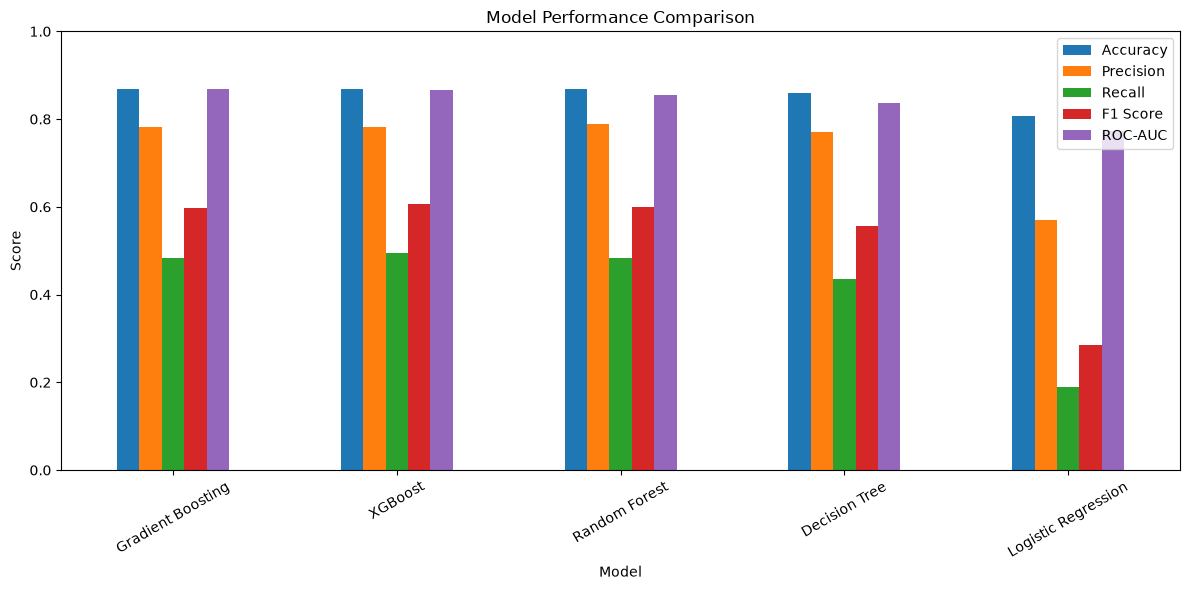

In [15]:
plt.figure(figsize=(10, 6))

comparison_plot = model_comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [16]:
best_model_name = model_comparison.iloc[0]["Model"]

print("Model selected using ROC-AUC:", best_model_name)

Model selected using ROC-AUC: Gradient Boosting


In [17]:
final_model = trained_models[best_model_name]

print(final_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary',
                                                   'BalanceSalaryRatio',
                                                   'ProductDensity',
                                                  

In [18]:
final_predictions = final_model.predict(X_test)

print(
    classification_report(
        y_test,
        final_predictions
    )
)

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000



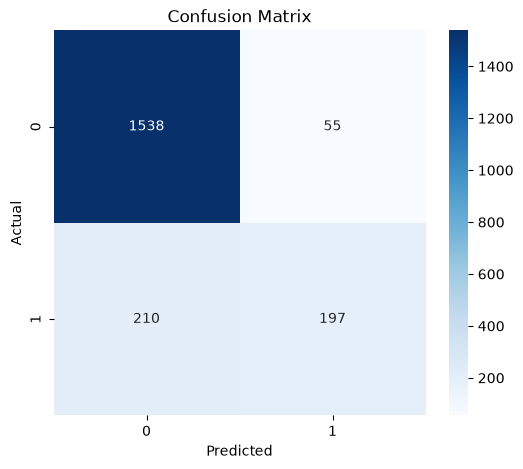

In [19]:
cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

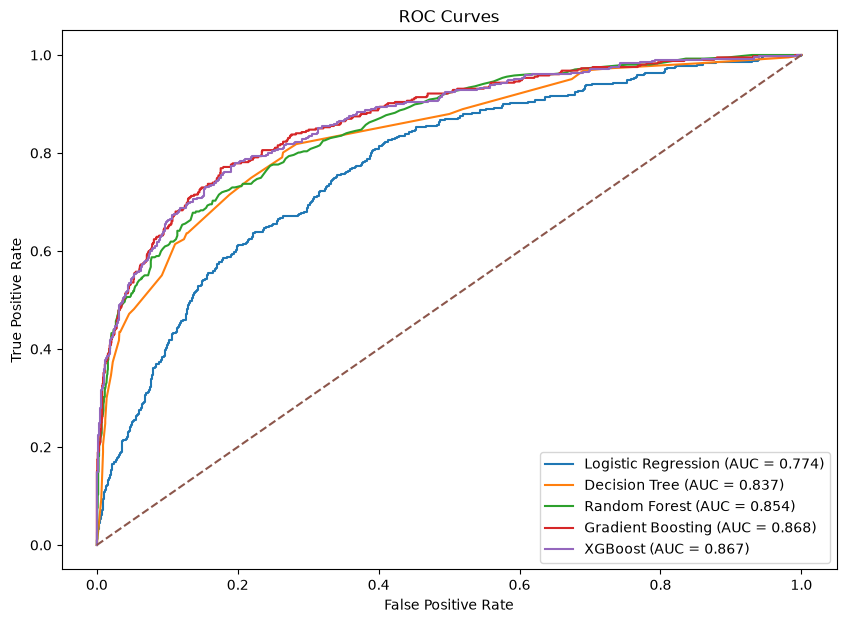

In [20]:
plt.figure(figsize=(10, 7))

for name, model in trained_models.items():

    probabilities = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [21]:
churn_probability = final_model.predict_proba(
    X_test
)[:, 1]

print(churn_probability[:10])

[0.02334518 0.08498154 0.04083456 0.04670511 0.11164717 0.16946308
 0.05876582 0.29644737 0.50531528 0.08211723]


In [22]:
risk_score = churn_probability * 100

In [23]:
def get_risk_category(score):

    if score < 30:
        return "Low"

    elif score < 60:
        return "Moderate"

    elif score < 80:
        return "High"

    else:
        return "Very High"

In [24]:
risk_category = [
    get_risk_category(score)
    for score in risk_score
]

In [25]:
risk_predictions = X_test.copy()

risk_predictions["ActualExited"] = y_test.values

risk_predictions["ChurnProbability"] = churn_probability

risk_predictions["RiskScore"] = risk_score

risk_predictions["RiskCategory"] = risk_category

risk_predictions["PredictedExited"] = final_predictions

risk_predictions.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,ProductDensity,EngagementProductInteraction,AgeTenureInteraction,ActualExited,ChurnProbability,RiskScore,RiskCategory,PredictedExited
0,2025,585,France,Male,36,7,0.00,2,1,0,94283.09,0.000000,0.250000,0,252,0,0.023345,2.334518,Low,0
1,2025,525,Germany,Male,33,4,131023.76,2,0,0,55072.93,2.379052,0.400000,0,132,0,0.084982,8.498154,Low,0
2,2025,557,Spain,Female,40,4,0.00,2,0,1,105433.53,0.000000,0.400000,2,160,0,0.040835,4.083456,Low,0
3,2025,639,Spain,Male,34,5,139393.19,2,0,0,33950.08,4.105707,0.333333,0,170,0,0.046705,4.670511,Low,0
4,2025,640,Spain,Female,34,3,77826.80,1,1,1,168544.85,0.461754,0.250000,1,102,0,0.111647,11.164717,Low,0


In [26]:
high_risk_customers = risk_predictions.sort_values(
    "RiskScore",
    ascending=False
)

high_risk_customers.head(10)

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,ProductDensity,EngagementProductInteraction,AgeTenureInteraction,ActualExited,ChurnProbability,RiskScore,RiskCategory,PredictedExited
501,2025,738,Germany,Male,58,2,133745.44,4,1,0,28373.86,4.713519,1.333333,0,116,1,0.993719,99.371882,Very High,1
338,2025,834,Germany,Female,57,8,112281.60,3,1,0,140225.14,0.800718,0.333333,0,456,1,0.989182,98.918155,Very High,1
854,2025,675,France,Female,61,5,62055.17,3,1,0,166305.16,0.373138,0.500000,0,305,1,0.981190,98.118978,Very High,1
586,2025,547,Germany,Male,55,4,111362.76,3,1,0,16922.28,6.580448,0.600000,0,220,1,0.980304,98.030353,Very High,1
1974,2025,568,Germany,Male,43,5,87612.64,4,1,1,107155.40,0.817615,0.666667,4,215,1,0.971928,97.192841,Very High,1
74,2025,575,Germany,Male,49,7,121205.15,4,1,1,168080.53,0.721109,0.500000,4,343,1,0.971874,97.187449,Very High,1
248,2025,469,Germany,Female,52,8,139493.25,3,0,0,150093.32,0.929371,0.333333,0,416,1,0.971452,97.145192,Very High,1
394,2025,683,Spain,Male,56,7,50911.21,3,0,0,97629.31,0.521469,0.375000,0,392,1,0.971142,97.114202,Very High,1
654,2025,655,Spain,Male,38,3,250898.09,3,0,1,81054.00,3.095405,0.750000,3,114,1,0.970438,97.043824,Very High,1
615,2025,351,Germany,Female,57,4,163146.46,1,1,0,169621.69,0.961820,0.200000,0,228,1,0.969329,96.932923,Very High,1


In [27]:
risk_counts = (
    risk_predictions["RiskCategory"]
    .value_counts()
)

print(risk_counts)

RiskCategory
Low          1575
Moderate      241
Very High     102
High           82
Name: count, dtype: int64


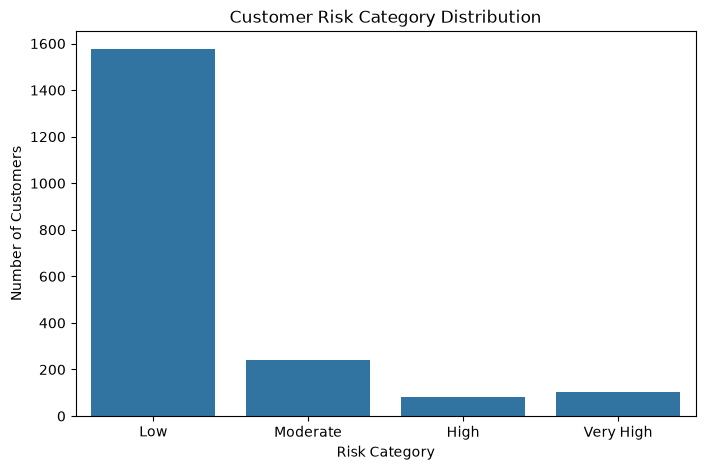

In [28]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=risk_predictions,
    x="RiskCategory",
    order=["Low", "Moderate", "High", "Very High"]
)

plt.title("Customer Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")

plt.show()

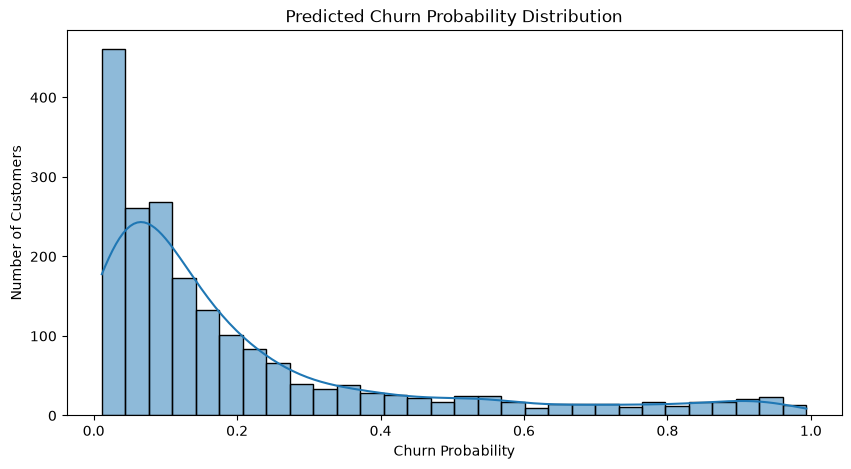

In [29]:
plt.figure(figsize=(10, 5))

sns.histplot(
    churn_probability,
    bins=30,
    kde=True
)

plt.title("Predicted Churn Probability Distribution")
plt.xlabel("Churn Probability")
plt.ylabel("Number of Customers")

plt.show()

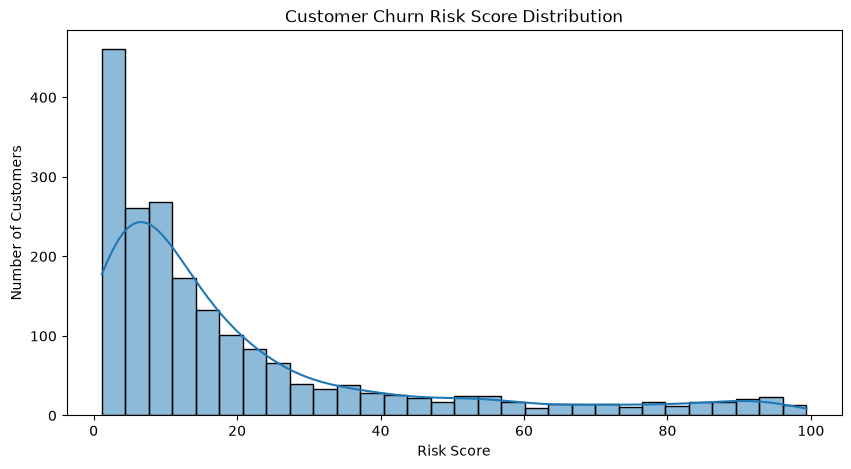

In [30]:
plt.figure(figsize=(10, 5))

sns.histplot(
    risk_score,
    bins=30,
    kde=True
)

plt.title("Customer Churn Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Number of Customers")

plt.show()

In [31]:
risk_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Average Risk Score",
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"
    ],
    "Value": [
        len(risk_predictions),
        round(risk_predictions["RiskScore"].mean(), 2),
        (risk_predictions["RiskCategory"] == "Low").sum(),
        (risk_predictions["RiskCategory"] == "Moderate").sum(),
        (risk_predictions["RiskCategory"] == "High").sum(),
        (risk_predictions["RiskCategory"] == "Very High").sum()
    ]
})

risk_summary

,Metric,Value
0,Total Customers,2000.00
1,Average Risk Score,20.57
2,Low Risk,1575.00
3,Moderate Risk,241.00
4,High Risk,82.00
5,Very High Risk,102.00


In [32]:
threshold_results = []

for threshold in np.arange(0.20, 0.81, 0.05):

    predictions = (
        churn_probability >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results.round(3)

,Threshold,Precision,Recall,F1 Score
0,0.20,0.510,0.774,0.615
1,0.25,0.577,0.713,0.637
2,0.30,0.621,0.649,0.635
3,0.35,0.668,0.602,0.633
4,0.40,0.709,0.558,0.624
5,0.45,0.747,0.516,0.610
6,0.50,0.782,0.484,0.598
7,0.55,0.833,0.428,0.565
8,0.60,0.864,0.391,0.538
9,0.65,0.890,0.359,0.511


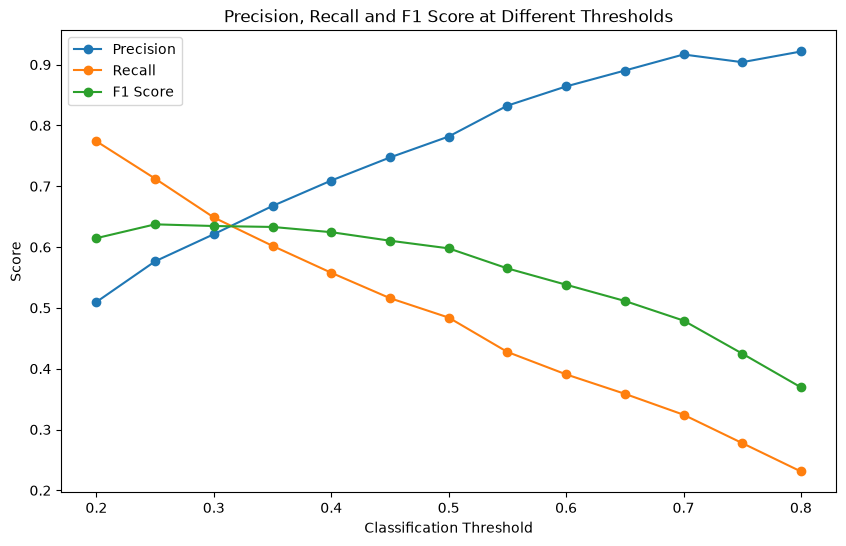

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 Score at Different Thresholds")
plt.legend()

plt.show()

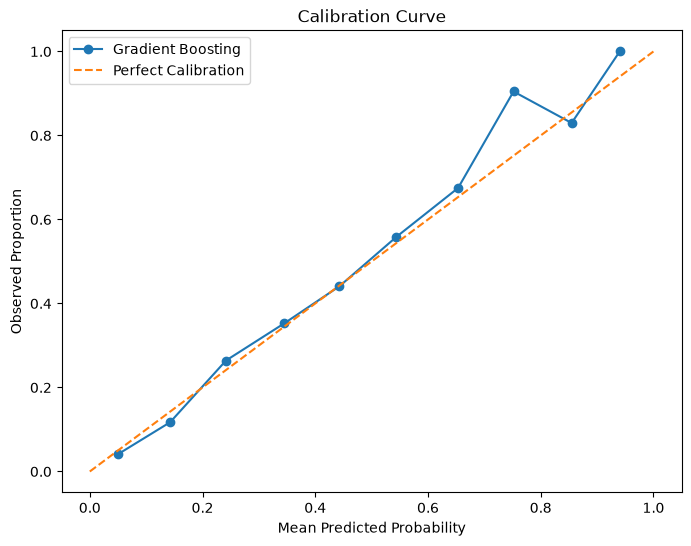

In [34]:
prob_true, prob_pred = calibration_curve(
    y_test,
    churn_probability,
    n_bins=10
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label=best_model_name
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Proportion")
plt.title("Calibration Curve")
plt.legend()

plt.show()

In [35]:
brier_score = brier_score_loss(
    y_test,
    churn_probability
)

print("Brier Score:", round(brier_score, 4))

Brier Score: 0.0995


In [36]:
joblib.dump(final_model, "final_model.pkl")

print("Final model saved as final_model.pkl")

Final model saved as final_model.pkl


In [37]:
risk_predictions.to_csv(
    "risk_predictions.csv",
    index=False
)

print("Risk predictions saved.")

Risk predictions saved.


In [38]:
model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

cv_results.to_csv(
    "cross_validation_results.csv",
    index=False
)

threshold_results.to_csv(
    "threshold_results.csv",
    index=False
)

print("Evaluation results saved.")

Evaluation results saved.


In [39]:
print("Final model:", best_model_name)

print(
    "Test ROC-AUC:",
    round(
        model_comparison.loc[
            model_comparison["Model"] == best_model_name,
            "ROC-AUC"
        ].iloc[0],
        4
    )
)

print(
    "Test F1 Score:",
    round(
        model_comparison.loc[
            model_comparison["Model"] == best_model_name,
            "F1 Score"
        ].iloc[0],
        4
    )
)

print(
    "Test Recall:",
    round(
        model_comparison.loc[
            model_comparison["Model"] == best_model_name,
            "Recall"
        ].iloc[0],
        4
    )
)

Final model: Gradient Boosting
Test ROC-AUC: 0.868
Test F1 Score: 0.5979
Test Recall: 0.484


In [40]:
print("Model development completed.")
print()
print("Models tested:")
for name in trained_models:
    print("-", name)

print()
print("Final model:", best_model_name)
print("Customers evaluated:", len(X_test))
print("Average risk score:", round(risk_score.mean(), 2))

Model development completed.

Models tested:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost

Final model: Gradient Boosting
Customers evaluated: 2000
Average risk score: 20.57


# Conclusion

Five machine learning models were developed and evaluated for bank customer churn prediction.

The models were compared using accuracy, precision, recall, F1 score and ROC-AUC. Stratified 5-fold cross-validation was used during model evaluation to provide a more reliable estimate of model performance.

The selected final model was based on the evaluation results rather than assuming a particular algorithm would perform best.

The final model produces a churn probability for each customer. This probability was converted into a 0-100 risk score and grouped into Low, Moderate, High and Very High risk categories.

Threshold analysis was also performed to understand the effect of changing the classification threshold. Probability calibration and Brier score were included because the project uses predicted probabilities for customer risk scoring.

The trained models, final model, evaluation results and risk predictions were saved for use in the explainability analysis and Streamlit application.